In [48]:
import os
import random
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from tqdm import tqdm
from PIL import Image
from collections import Counter
from multiprocessing import Pool, cpu_count

import torch
from torchvision import transforms
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')

In [49]:
INPUT_DIR  = "/kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images"
OUTPUT_DIR = "/kaggle/working/preprocessed"
META_PATH  = "/kaggle/working/meta.json"
CSV_PATH   = "/kaggle/working/split.csv"

IMAGE_SIZE  = 224
USE_RATIO   = 1.0
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = sorted(os.listdir(INPUT_DIR))
NUM_CLASSES = len(CLASS_NAMES)
SHORT_NAMES = [c.replace('Demented', '').replace('Non', 'Non-D') for c in CLASS_NAMES]
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Classes (4): ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [50]:
all_paths  = []
all_labels = []
class_sizes = {}

for idx, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(INPUT_DIR, cls)
    files   = [f for f in os.listdir(cls_dir)
               if os.path.isfile(os.path.join(cls_dir, f))]
    random.shuffle(files)
    n = int(len(files) * USE_RATIO)
    class_sizes[cls] = n
    for fname in files[:n]:
        all_paths.append(os.path.join(cls_dir, fname))
        all_labels.append(idx)

print(f"Total images: {len(all_paths)}")

Total images: 44000


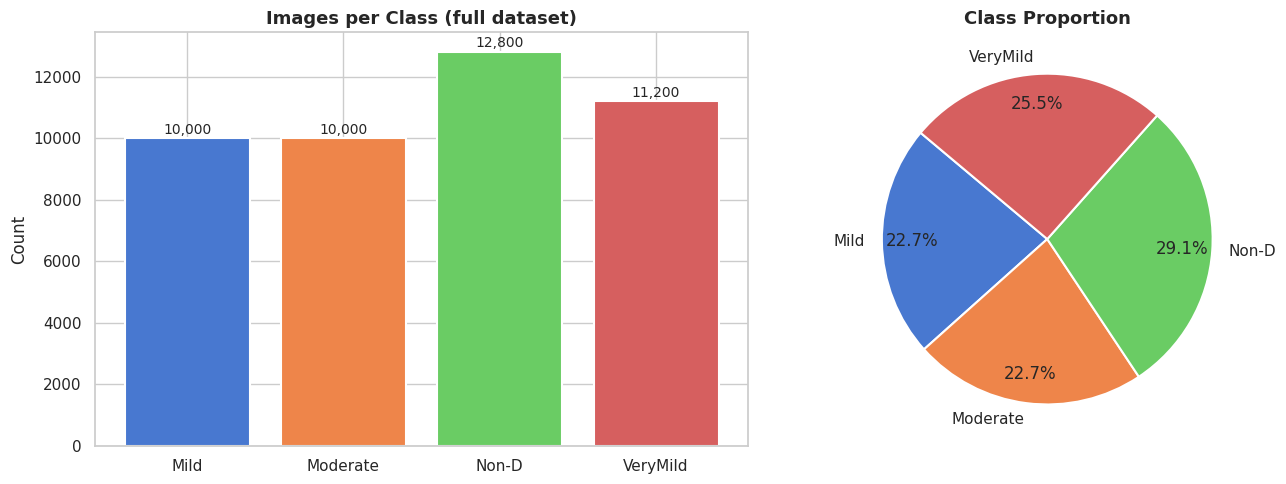

In [52]:
colors = sns.color_palette('muted', NUM_CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(SHORT_NAMES, class_sizes.values(), color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Images per Class (full dataset)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, class_sizes.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

axes[1].pie(class_sizes.values(), labels=SHORT_NAMES, colors=colors,
            autopct='%1.1f%%', startangle=140, pctdistance=0.82,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

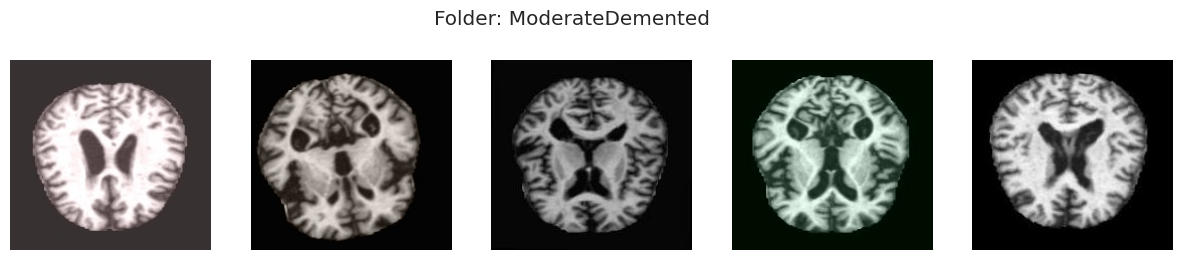

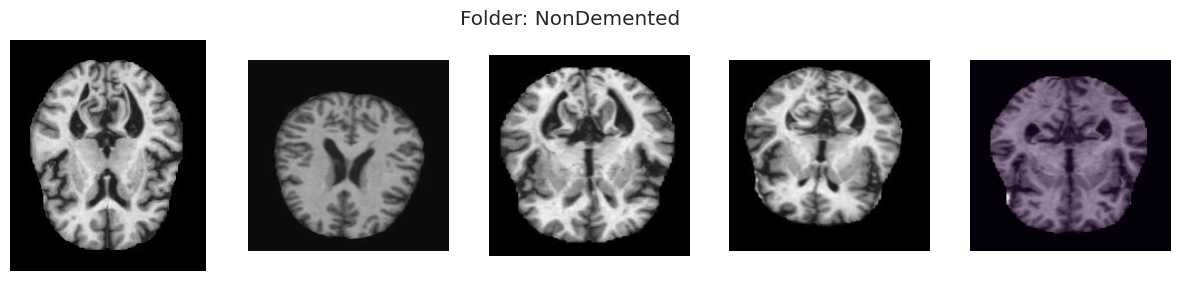

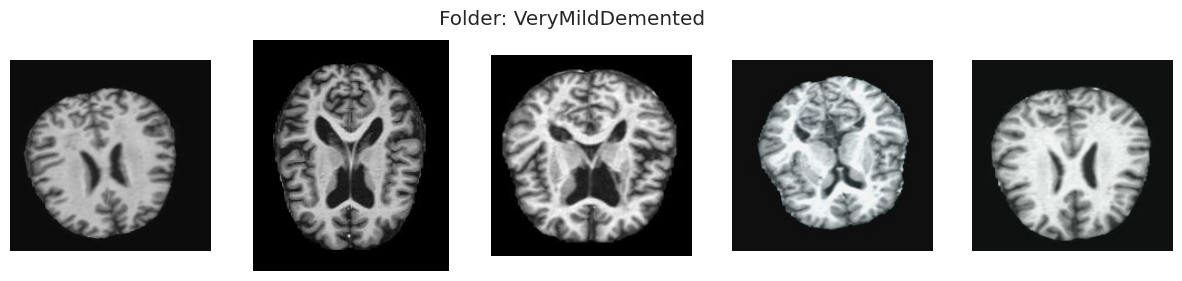

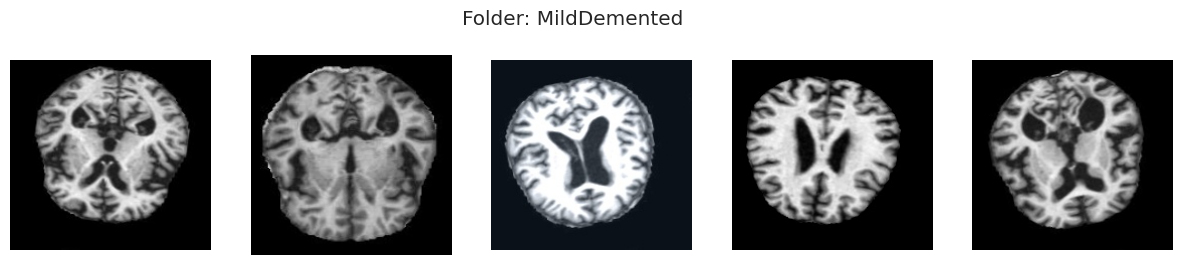

In [53]:
working_directory = INPUT_DIR
img_folders = os.listdir(working_directory)

for folder in img_folders:
    target_dir = os.path.join(working_directory, folder)
    five_images = os.listdir(target_dir)[:5]
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for ax, path in zip(axes, five_images):
        img_path = os.path.join(target_dir, path)
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
    plt.suptitle(f"Folder: {folder}")
    plt.show()

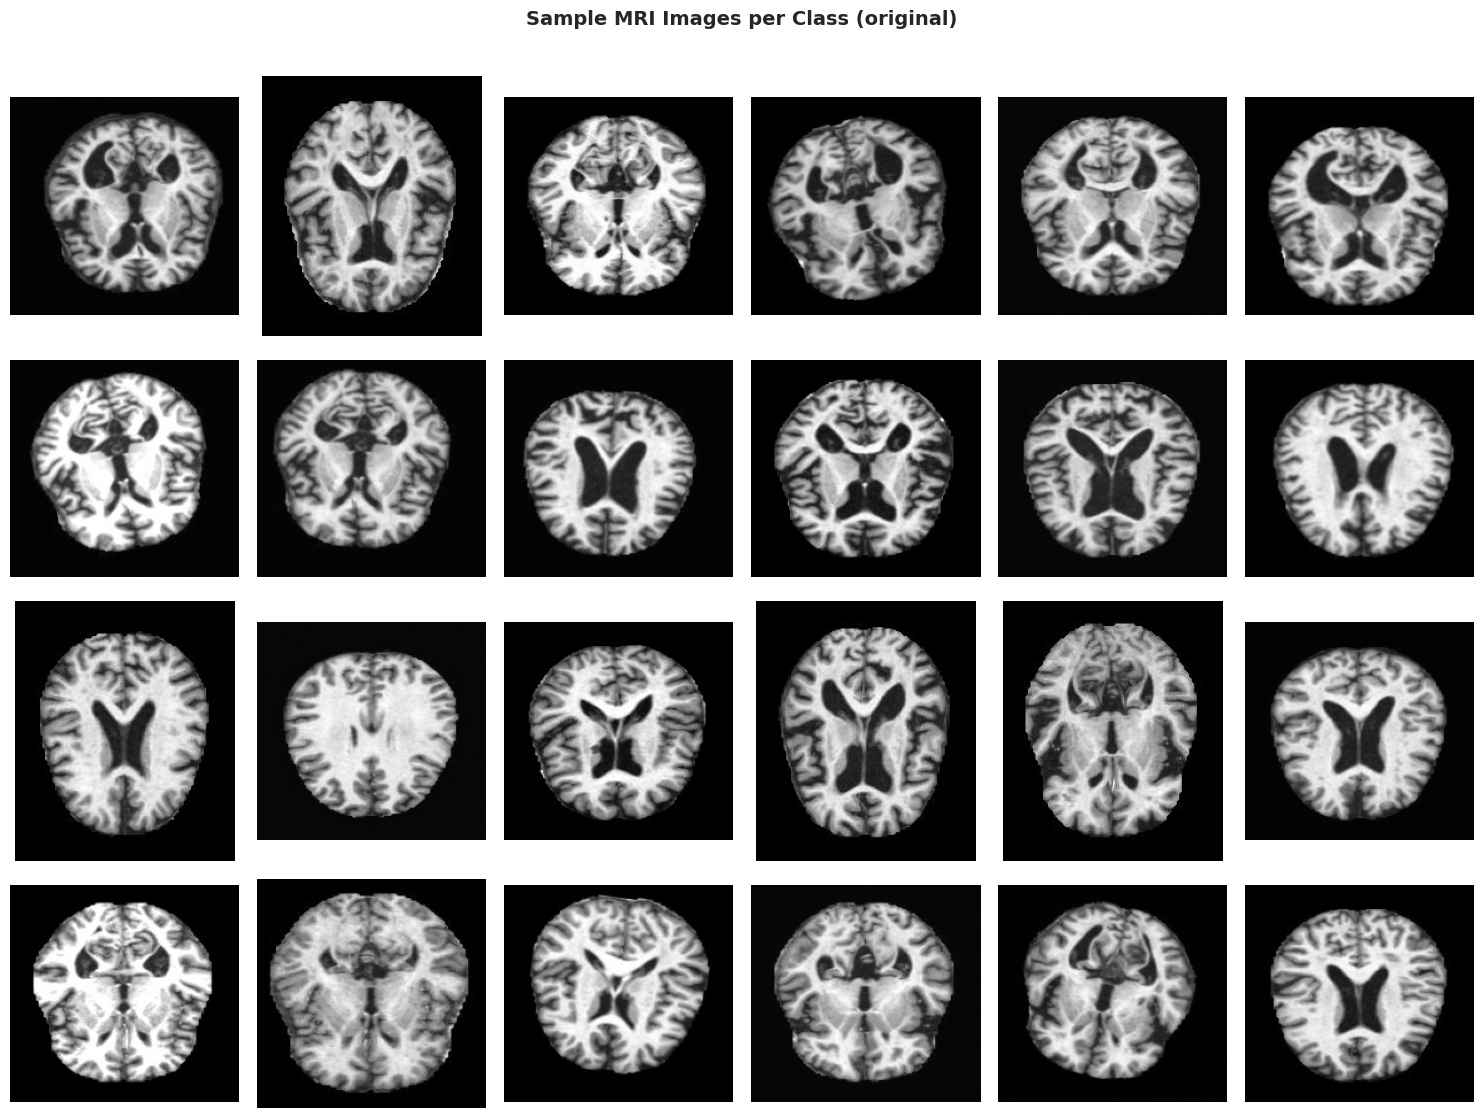

In [54]:
N_SAMPLES = 6

fig, axes = plt.subplots(NUM_CLASSES, N_SAMPLES,
                         figsize=(N_SAMPLES * 2.5, NUM_CLASSES * 2.8))
fig.suptitle('Sample MRI Images per Class (original)', fontsize=14, fontweight='bold', y=1.01)

for row, (cls, label) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    samples   = random.sample(cls_paths, N_SAMPLES)
    for col, path in enumerate(samples):
        img = Image.open(path).convert('L')
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(SHORT_NAMES[row], fontsize=11,
                                      fontweight='bold', rotation=0,
                                      labelpad=60, va='center')

plt.tight_layout()
plt.show()

In [55]:
data = []
for folder_name in os.listdir(working_directory):
    folder_path = os.path.join(working_directory, folder_name)
    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            data.append({
                'FilePath': os.path.join(folder_path, img_name),
                'Label': folder_name
            })

df = pd.DataFrame(data)
print(f"Total images found and stored in the DataFrame: {len(df)}")
df.head()

Total images found and stored in the DataFrame: 44000


,FilePath,Label
0,/kaggle/input/datasets/aryansinghal10/alzheime...,ModerateDemented
1,/kaggle/input/datasets/aryansinghal10/alzheime...,ModerateDemented
2,/kaggle/input/datasets/aryansinghal10/alzheime...,ModerateDemented
3,/kaggle/input/datasets/aryansinghal10/alzheime...,ModerateDemented
4,/kaggle/input/datasets/aryansinghal10/alzheime...,ModerateDemented


In [56]:
def read_image_metadata(path):
    try:
        with Image.open(path) as img:
            return [img.size[0], img.size[1], img.size, img.mode, len(img.getbands())]
    except:
        return [None, None, None, None, None]

def collect_image_metadata(df):
    num_cores = cpu_count()
    print(f"Launching {num_cores} parallel workers...")
    with Pool(num_cores) as pool:
        results = list(tqdm(pool.imap(read_image_metadata, df['FilePath']),
                           total=len(df),
                           desc="Multiprocessing Extraction"))
    meta_columns = ['Width', 'Height', 'Size', 'Mode', 'Channels']
    meta_df = pd.DataFrame(results, columns=meta_columns)
    return pd.concat([df.reset_index(drop=True), meta_df], axis=1)

df = collect_image_metadata(df)

Launching 4 parallel workers...


Multiprocessing Extraction: 100%|██████████| 44000/44000 [00:10<00:00, 4398.52it/s]


In [57]:
print(f"Number of Images that failed to process: {df['Width'].isnull().sum()} images")
print("\nDistribution of Image Sizes")
print(df['Size'].value_counts().reset_index())

Number of Images that failed to process: 0 images

Distribution of Image Sizes
         Size  count
0  (200, 190)  31107
1  (180, 180)   6447
2  (176, 208)   6446


In [58]:
print("Bias Audit of Size and their Labels")
print(df.groupby(['Size', 'Label']).size().unstack())

Bias Audit of Size and their Labels
Label       MildDemented  ModerateDemented  NonDemented  VeryMildDemented
Size                                                                     
(176, 208)           911                95         3200              2240
(180, 180)           913                94         3200              2240
(200, 190)          8176              9811         6400              6720


In [59]:
print("\nDistribution of Image Modes/Channels")
print(df['Mode'].value_counts().reset_index())


Distribution of Image Modes/Channels
  Mode  count
0  RGB  33984
1    L  10016


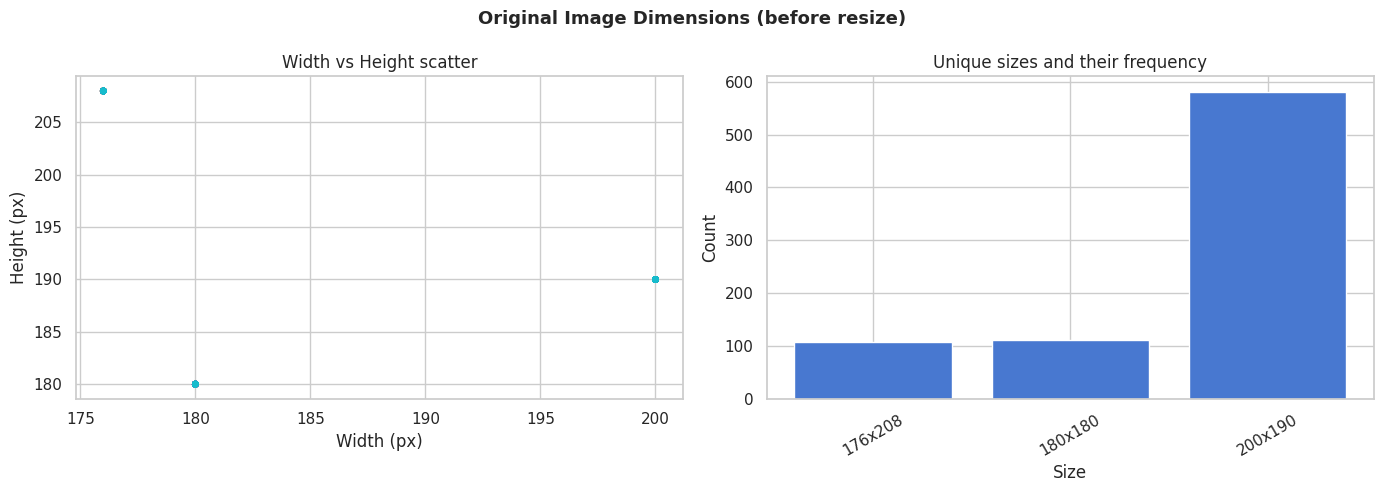

Unique sizes found: 3
 width  height  count
   176     208    108
   180     180    111
   200     190    581


In [60]:
N_SIZE_SAMPLES = 200
widths, heights, size_labels = [], [], []

for cls, label in zip(CLASS_NAMES, range(NUM_CLASSES)):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    for path in random.sample(cls_paths, min(N_SIZE_SAMPLES, len(cls_paths))):
        w, h = Image.open(path).size
        widths.append(w)
        heights.append(h)
        size_labels.append(SHORT_NAMES[label])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Original Image Dimensions (before resize)', fontsize=13, fontweight='bold')

label_to_id = {name: i for i, name in enumerate(SHORT_NAMES)}
color_ids = [label_to_id[lbl] for lbl in size_labels]

axes[0].scatter(widths, heights, c=color_ids, alpha=0.4, cmap='tab10', s=15)
axes[0].set_xlabel('Width (px)'); axes[0].set_ylabel('Height (px)')
axes[0].set_title('Width vs Height scatter')

size_df = pd.DataFrame({'width': widths, 'height': heights, 'class': size_labels})
unique_sizes = size_df.groupby(['width', 'height']).size().reset_index(name='count')
axes[1].bar(range(len(unique_sizes)), unique_sizes['count'],
            tick_label=[f"{r.width}x{r.height}" for r in unique_sizes.itertuples()])
axes[1].set_title('Unique sizes and their frequency')
axes[1].set_xlabel('Size'); axes[1].set_ylabel('Count')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()
print(f"Unique sizes found: {len(unique_sizes)}")
print(unique_sizes.to_string(index=False))

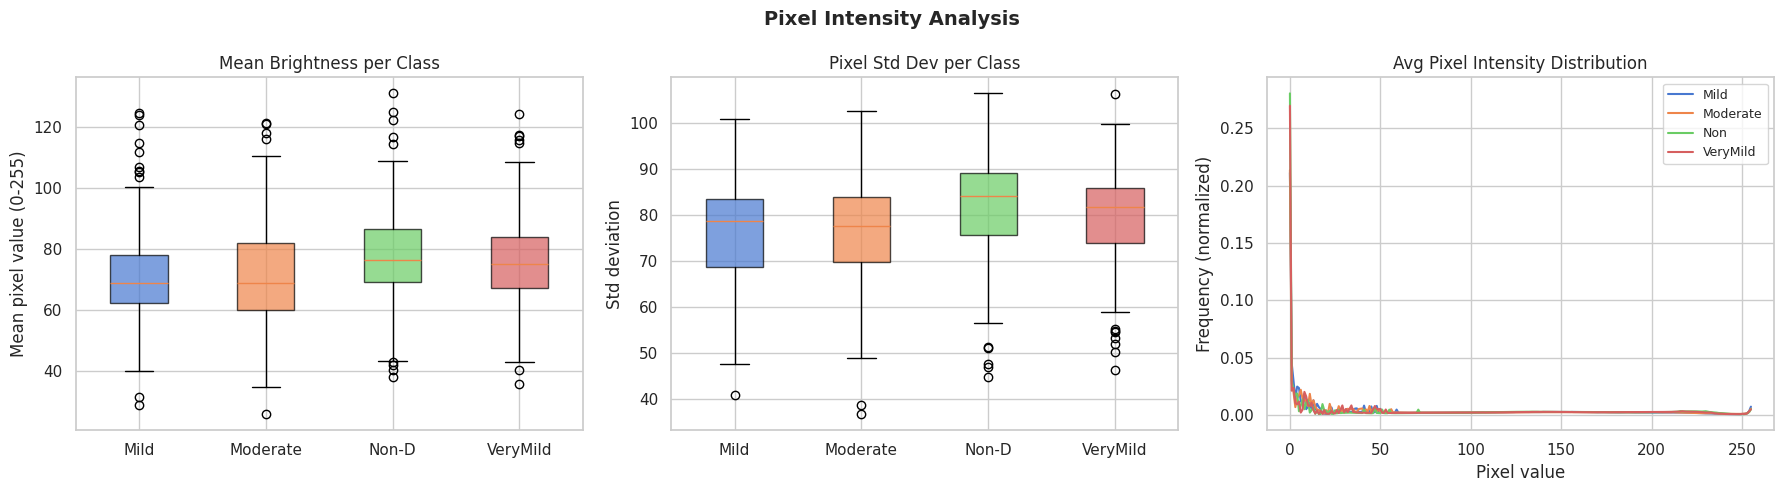

In [61]:
N_STAT_SAMPLES = 150

class_means = {cls: [] for cls in CLASS_NAMES}
class_stds  = {cls: [] for cls in CLASS_NAMES}
histograms  = {cls: np.zeros(256) for cls in CLASS_NAMES}

for cls, label in zip(CLASS_NAMES, range(NUM_CLASSES)):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    samples   = random.sample(cls_paths, min(N_STAT_SAMPLES, len(cls_paths)))
    for path in tqdm(samples, desc=f'Stats {cls}', leave=False):
        arr = np.array(Image.open(path).convert('L'))
        class_means[cls].append(arr.mean())
        class_stds[cls].append(arr.std())
        hist, _ = np.histogram(arr, bins=256, range=(0, 255))
        histograms[cls] += hist

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pixel Intensity Analysis', fontsize=14, fontweight='bold')

box_data = [class_means[cls] for cls in CLASS_NAMES]
bp = axes[0].boxplot(box_data, patch_artist=True, labels=SHORT_NAMES)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Mean Brightness per Class')
axes[0].set_ylabel('Mean pixel value (0-255)')

std_data = [class_stds[cls] for cls in CLASS_NAMES]
bp2 = axes[1].boxplot(std_data, patch_artist=True, labels=SHORT_NAMES)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Pixel Std Dev per Class')
axes[1].set_ylabel('Std deviation')

for cls, color in zip(CLASS_NAMES, colors):
    normed = histograms[cls] / histograms[cls].sum()
    axes[2].plot(normed, label=cls.replace('Demented','').strip(), color=color, linewidth=1.5)
axes[2].set_title('Avg Pixel Intensity Distribution')
axes[2].set_xlabel('Pixel value')
axes[2].set_ylabel('Frequency (normalized)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

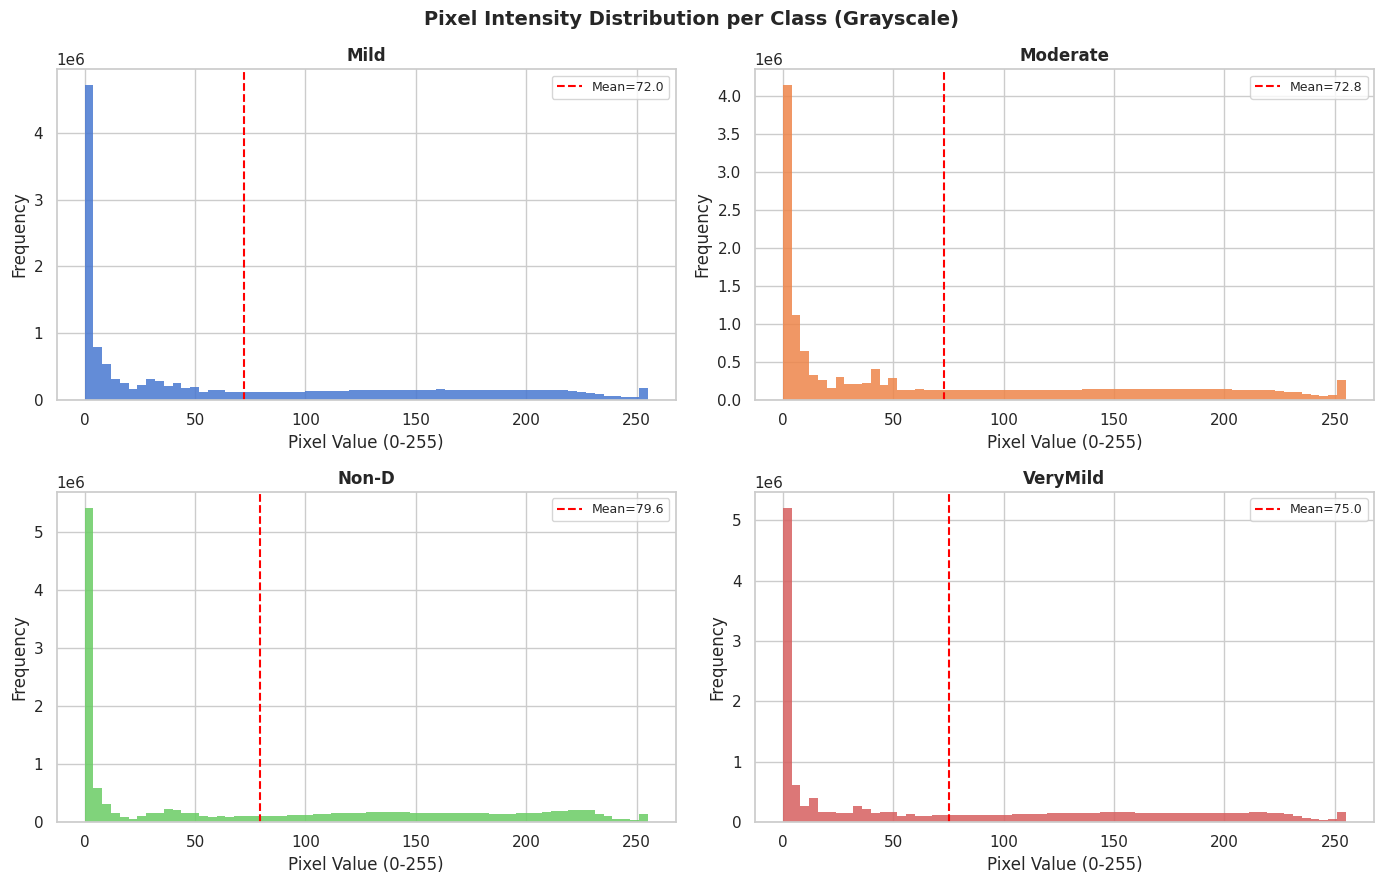

In [62]:
EDA_SAMPLES = 300
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
fig.suptitle('Pixel Intensity Distribution per Class (Grayscale)', fontsize=14, fontweight='bold')

for idx, (cls, label) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    sampled   = random.sample(cls_paths, min(EDA_SAMPLES, len(cls_paths)))
    all_pixels = []
    for path in sampled:
        img = np.array(Image.open(path).convert('L').resize((224, 224))).flatten()
        all_pixels.extend(img.tolist())
    all_pixels = np.array(all_pixels)
    axes[idx].hist(all_pixels, bins=64, color=sns.color_palette('muted')[idx],
                   alpha=0.85, edgecolor='none')
    axes[idx].axvline(all_pixels.mean(), color='red', linestyle='--', linewidth=1.5,
                      label=f'Mean={all_pixels.mean():.1f}')
    axes[idx].set_title(SHORT_NAMES[idx], fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Pixel Value (0-255)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.show()

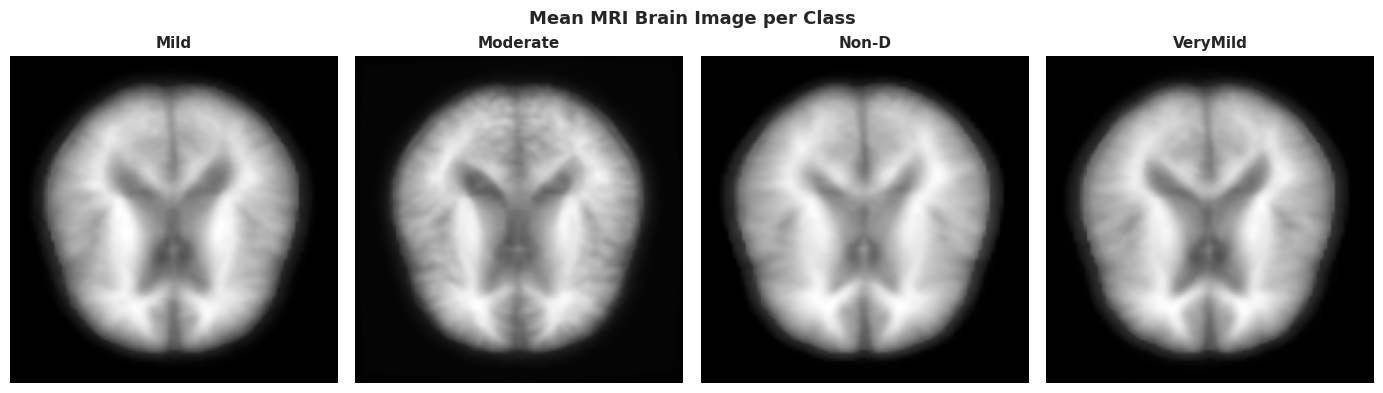

In [63]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 4))
fig.suptitle('Mean MRI Brain Image per Class', fontsize=13, fontweight='bold')

mean_imgs = {}
for idx, (cls, label) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    sampled   = random.sample(cls_paths, min(EDA_SAMPLES, len(cls_paths)))
    stack = np.stack([
        np.array(Image.open(p).convert('L').resize((224, 224)), dtype=np.float32)
        for p in sampled
    ])
    mean_img = stack.mean(axis=0).astype(np.uint8)
    mean_imgs[cls] = mean_img
    axes[idx].imshow(mean_img, cmap='gray')
    axes[idx].set_title(SHORT_NAMES[idx], fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

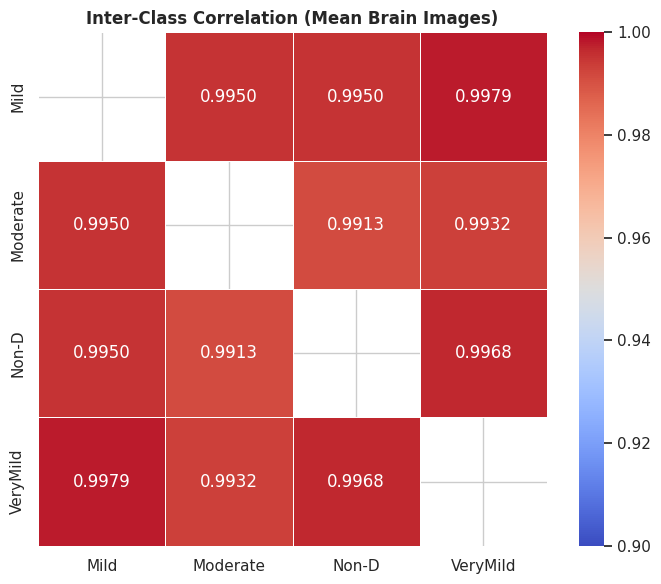

In [64]:
mean_flat = np.stack([mean_imgs[cls].flatten() for cls in CLASS_NAMES])
corr_matrix = np.corrcoef(mean_flat)

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            linewidths=0.5, ax=ax, vmin=0.9, vmax=1.0, mask=mask)
np.fill_diagonal(corr_matrix, np.nan)
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            linewidths=0.5, ax=ax, vmin=0.9, vmax=1.0,
            cbar=False, mask=~mask.__invert__().__invert__().__invert__().__invert__())
ax.set_title('Inter-Class Correlation (Mean Brain Images)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

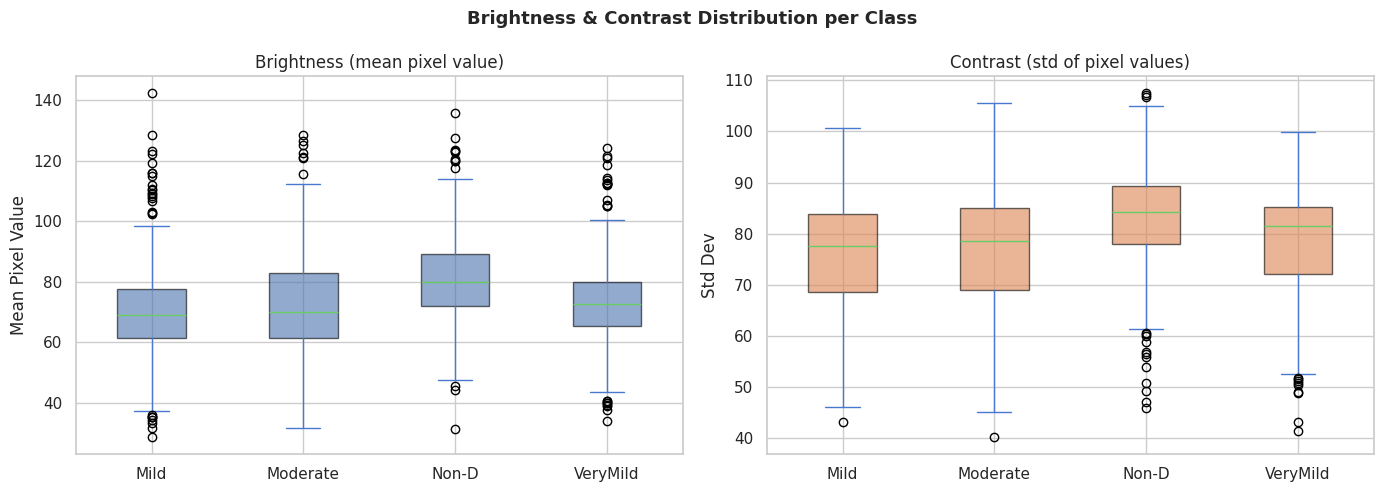


=== Brightness Stats ===
         Mild  Moderate   Non-D  VeryMild
count  300.00    300.00  300.00    300.00
mean    70.21     72.41   80.97     73.02
std     17.23     18.58   15.34     15.78
min     28.84     31.80   31.47     34.01
25%     61.48     61.39   71.88     65.33
50%     69.00     70.04   80.03     72.59
75%     77.68     82.95   89.11     80.05
max    142.31    128.63  135.75    124.26

=== Contrast Stats ===
         Mild  Moderate   Non-D  VeryMild
count  300.00    300.00  300.00    300.00
mean    76.07     76.62   82.85     78.11
std     11.36     12.06   10.44     11.12
min     43.14     40.31   45.94     41.36
25%     68.57     68.93   78.04     72.04
50%     77.68     78.51   84.16     81.53
75%     83.83     85.06   89.30     85.27
max    100.72    105.59  107.41     99.79


In [65]:
brightness_data = {cls: [] for cls in CLASS_NAMES}
contrast_data   = {cls: [] for cls in CLASS_NAMES}

for idx, (cls, label) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    sampled   = random.sample(cls_paths, min(EDA_SAMPLES, len(cls_paths)))
    for path in sampled:
        arr = np.array(Image.open(path).convert('L').resize((224, 224)), dtype=np.float32)
        brightness_data[cls].append(arr.mean())
        contrast_data[cls].append(arr.std())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Brightness & Contrast Distribution per Class', fontsize=13, fontweight='bold')

bright_df   = pd.DataFrame({k: pd.Series(v) for k, v in brightness_data.items()})
contrast_df = pd.DataFrame({k: pd.Series(v) for k, v in contrast_data.items()})
bright_df.columns   = SHORT_NAMES
contrast_df.columns = SHORT_NAMES

bright_df.plot(kind='box', ax=axes[0], patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[0].set_title('Brightness (mean pixel value)'); axes[0].set_ylabel('Mean Pixel Value')

contrast_df.plot(kind='box', ax=axes[1], patch_artist=True,
                 boxprops=dict(facecolor='#DD8452', alpha=0.6))
axes[1].set_title('Contrast (std of pixel values)'); axes[1].set_ylabel('Std Dev')

plt.tight_layout()
plt.show()

print("\n=== Brightness Stats ===")
print(bright_df.describe().round(2).to_string())
print("\n=== Contrast Stats ===")
print(contrast_df.describe().round(2).to_string())

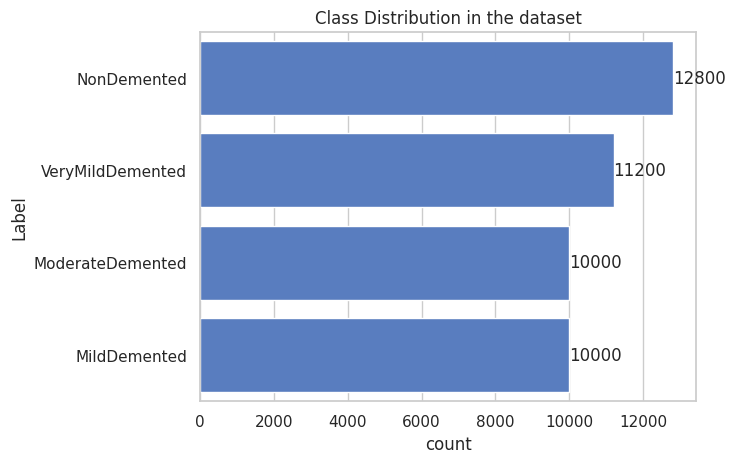

In [66]:
sns.countplot(data=df, y='Label', order=df['Label'].value_counts().index)
plt.title('Class Distribution in the dataset')
ax = plt.gca()
ax.bar_label(ax.containers[0])
plt.show()

In [67]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=1 - TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")
for name, lbls in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    c = Counter(lbls)
    print(f"  {name}:", {CLASS_NAMES[k]: v for k, v in sorted(c.items())})

Train: 35200 | Val: 4400 | Test: 4400
  train: {'MildDemented': 8000, 'ModerateDemented': 8000, 'NonDemented': 10240, 'VeryMildDemented': 8960}
  val: {'MildDemented': 1000, 'ModerateDemented': 1000, 'NonDemented': 1280, 'VeryMildDemented': 1120}
  test: {'MildDemented': 1000, 'ModerateDemented': 1000, 'NonDemented': 1280, 'VeryMildDemented': 1120}


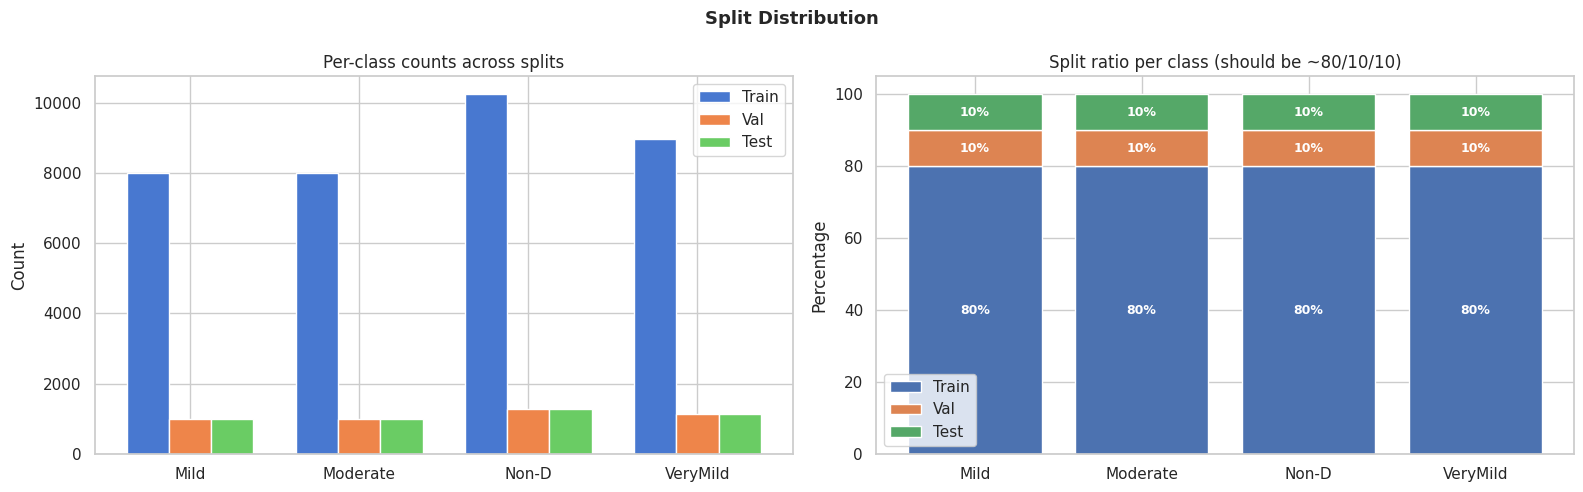

In [68]:
split_data = {}
for sname, lbls in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    c = Counter(lbls)
    split_data[sname] = [c[i] for i in range(NUM_CLASSES)]

x     = np.arange(NUM_CLASSES)
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Split Distribution', fontsize=13, fontweight='bold')

for i, (sname, counts) in enumerate(split_data.items()):
    axes[0].bar(x + i*width, counts, width, label=sname)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(SHORT_NAMES)
axes[0].set_ylabel('Count')
axes[0].set_title('Per-class counts across splits')
axes[0].legend()

totals = np.array([sum(split_data[s][i] for s in split_data) for i in range(NUM_CLASSES)])
bottom = np.zeros(NUM_CLASSES)
split_colors = ['#4C72B0', '#DD8452', '#55A868']
for (sname, counts), sc in zip(split_data.items(), split_colors):
    pct = np.array(counts) / totals * 100
    axes[1].bar(SHORT_NAMES, pct, bottom=bottom, label=sname, color=sc)
    for j, (p, b) in enumerate(zip(pct, bottom)):
        axes[1].text(j, b + p/2, f'{p:.0f}%', ha='center', va='center',
                     fontsize=9, color='white', fontweight='bold')
    bottom += pct
axes[1].set_ylabel('Percentage')
axes[1].set_title('Split ratio per class (should be ~80/10/10)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [69]:
label_map = {
    'NonDemented': 0,
    'VeryMildDemented': 1,
    'MildDemented': 2,
    'ModerateDemented': 3
}

train_val_df, test_df_eff = train_test_split(
    df, test_size=0.10, stratify=df['Label'], random_state=42)
train_df_eff, val_df_eff = train_test_split(
    train_val_df, test_size=0.1111, stratify=train_val_df['Label'], random_state=42)

for name, split_df in [("Train", train_df_eff), ("Val", val_df_eff), ("Test", test_df_eff)]:
    print(f"\n{name} Distribution")
    percentages = split_df["Label"].value_counts(normalize=True) * 100
    print(percentages)


Train Distribution
Label
NonDemented         29.090909
VeryMildDemented    25.454545
MildDemented        22.727273
ModerateDemented    22.727273
Name: proportion, dtype: float64

Val Distribution
Label
NonDemented         29.090909
VeryMildDemented    25.454545
ModerateDemented    22.727273
MildDemented        22.727273
Name: proportion, dtype: float64

Test Distribution
Label
NonDemented         29.090909
VeryMildDemented    25.454545
ModerateDemented    22.727273
MildDemented        22.727273
Name: proportion, dtype: float64
